Анализ каталога Nike за 2026 год.
**Цель:** изучить структуру глобальгого каталога Nike: распределение по категориям, цены и скидки.

1. Загружаем данные и библиотеки.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Global_Nike.csv')
df.head()

,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,...,canonical_url,image_url,gtin,stock_keeping_unit_id,catalog_sku_id,nike_size,localized_size,size_conversion_id,sport_tags,record_source
0,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,L,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,39559a5b-10fa-3043-b76d-3768a55e1497,L,L,634c88b1-1341-378c-91c2-694b4d4af924,Football,thread_exact
1,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,M,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,c86c12ba-1f5a-35e9-b7b1-4b99c951697a,M,M,cb181d5c-38b4-3423-a1a4-aa7d8c6f0bc7,Football,thread_exact
2,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,S,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,2a8280da-2422-367d-8b62-815fd818558b,S,S,ee441df8-f44d-3452-abf3-80619a6b7376,Football,thread_exact
3,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,XL,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,f57b1501-4949-367c-9ef2-e0a97950bed1,XL,XL,63c009fa-41e9-37f7-8207-2131d668fc30,Football,thread_exact
4,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,XXL,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,33558d9d-c59c-3040-abb7-0504ea8fc36b,2XL,XXL,7c41b818-d111-3baf-a3d9-2f0a21a35ff5,Football,thread_exact


2. Смотрим на типы данных.

In [51]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447795 entries, 0 to 1447794
Data columns (total 35 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   snapshot_date          1447795 non-null  object 
 1   country_code           1447795 non-null  object 
 2   product_name           1447795 non-null  object 
 3   model_number           1447795 non-null  object 
 4   currency               1447795 non-null  object 
 5   price_local            1447795 non-null  float64
 6   sale_price_local       210687 non-null   float64
 7   gender_segment         1441048 non-null  object 
 8   size_label             1447793 non-null  object 
 9   category               1447795 non-null  object 
 10  subcategory            1447767 non-null  object 
 11  product_id             1447795 non-null  object 
 12  sku                    1447793 non-null  object 
 13  style_color            1447795 non-null  object 
 14  brand_name        

,price_local,sale_price_local,size_count,available_size_count,discount_pct,employee_price,gtin,stock_keeping_unit_id
count,1.447795e+06,2.106870e+05,0.0,0.0,1.447777e+06,0.0,0.0,1.447793e+06
mean,6.555476e+04,1.360314e+05,NaN,NaN,3.600409e+00,NaN,NaN,9.032503e+08
std,4.386498e+05,6.354138e+05,NaN,NaN,9.167788e+00,NaN,NaN,2.984759e+08
min,0.000000e+00,8.990000e+00,NaN,NaN,-2.027270e+01,NaN,NaN,1.000702e+07
25%,7.499000e+01,1.099900e+02,NaN,NaN,0.000000e+00,NaN,NaN,1.004106e+09
50%,1.399900e+02,3.690000e+02,NaN,NaN,0.000000e+00,NaN,NaN,1.005086e+09
75%,6.299900e+02,3.149000e+03,NaN,NaN,0.000000e+00,NaN,NaN,1.005424e+09
max,1.079900e+07,1.030900e+07,NaN,NaN,5.081540e+01,NaN,NaN,1.007658e+09


3. Очищаем наш DataFrame от ненужной информации.

In [52]:
columns_keep = [
    'product_name',
    'price_local',
    'sale_price_local',
    'discount_pct',
    'gender_segment',
    'category',
    'subcategory',
    'color_name',
    'sport_tags'
]

df_clean = df[columns_keep].copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447795 entries, 0 to 1447794
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   product_name      1447795 non-null  object 
 1   price_local       1447795 non-null  float64
 2   sale_price_local  210687 non-null   float64
 3   discount_pct      1447777 non-null  float64
 4   gender_segment    1441048 non-null  object 
 5   category          1447795 non-null  object 
 6   subcategory       1447767 non-null  object 
 7   color_name        1447748 non-null  object 
 8   sport_tags        1445530 non-null  object 
dtypes: float64(3), object(6)
memory usage: 99.4+ MB


4. Проанализируем структуру нашего каталога на данный момент и построим график.

category
FOOTWEAR              724811
APPAREL               696577
EQUIPMENT              26389
PHYSICAL_GIFT_CARD        16
DIGITAL_GIFT_CARD          2
Name: count, dtype: int64


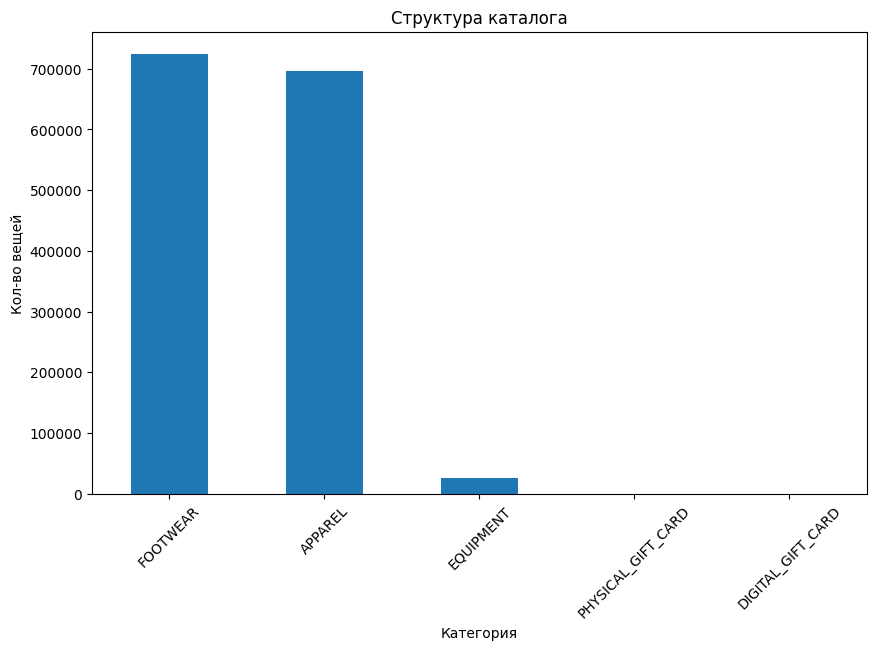

In [53]:
print(df_clean['category'].value_counts())
plt.figure(figsize=(10,6))
df_clean['category'].value_counts().plot(kind='bar')
plt.title('Структура каталога')
plt.xlabel('Категория')
plt.ylabel('Кол-во вещей')
plt.xticks(rotation = 45)
plt.show()

Имеем следующую структуру каталога:


*   Apparel - 208545 ед.
*   Footwear - 171833 ед.
*   Equipment - 7401 ед.
*   Physical Gift Card - 6 ед.
*   Digital Gift Card - 2 ед.







5. Считаем количество товара со скидкой.

In [54]:
df_clean['has_discount'] = df_clean['sale_price_local'].notna()
discount_count = df_clean['has_discount'].sum()
total_count = len(df_clean)

print(f'Всего товаров: {total_count}')
print(f'Товаров со скидкой: {discount_count}')
print(f'Процент товаров со скидкой: {(discount_count/total_count) * 100:.1f}%')

discount_by_category = df_clean.groupby('category')['has_discount'].mean() * 100
print(discount_by_category)

Всего товаров: 1447795
Товаров со скидкой: 210687
Процент товаров со скидкой: 14.6%
category
APPAREL               13.000860
DIGITAL_GIFT_CARD      0.000000
EQUIPMENT              9.037857
FOOTWEAR              16.244373
PHYSICAL_GIFT_CARD     0.000000
Name: has_discount, dtype: float64


6. Построим график скидок по категориям.

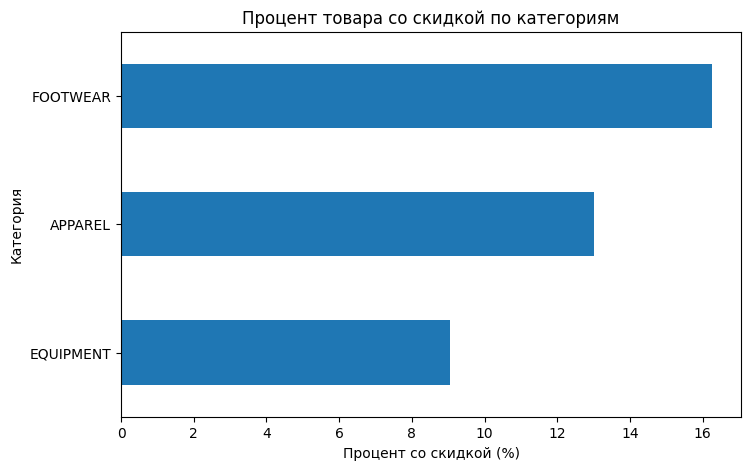

In [55]:
discount_filtered = discount_by_category.drop(['PHYSICAL_GIFT_CARD', 'DIGITAL_GIFT_CARD'], errors='ignore')

plt.figure(figsize=(8, 5))
discount_filtered.sort_values().plot(kind='barh')
plt.title('Процент товара со скидкой по категориям')
plt.xlabel('Процент со скидкой (%)')
plt.ylabel('Категория')
plt.show()

Вывод по скидкам.

*   Всего со скидкой продаётся 14.9% товара (210687 из 1447795)
*   Чаще всего скидка встречается в категории **Footwear** - 16.24%
*   Реже всего - в **Equipment** - 9.03%



7. Изучим валюты нашего каталога для корректного анализа цен.

In [56]:
df_clean['currency'] = df['currency']
print(df_clean['currency'].value_counts())

currency
EUR    719260
USD     69949
JPY     43306
GBP     39765
DKK     39362
PLN     39186
SEK     38519
CHF     38088
CNY     37547
ILS     36874
RON     36811
ZAR     36663
CAD     33730
TRY     30034
PHP     22967
SGD     22967
MYR     22602
IDR     22499
THB     21929
TWD     21036
VND     20115
MXN     19569
KRW     15636
NOK     15363
INR      2038
NZD      1501
BGN       244
AUD       230
EGP         5
Name: count, dtype: int64


8. Переведём все цены в доллары и посчитаем среднюю цену по категориям.

In [57]:
manual_rates = {
    'USD': 1.0,
    'EUR': 0.92,
    'GBP': 0.79,
    'JPY': 149.0,
    'DKK': 6.85,
    'PLN': 3.95,
    'SEK': 10.55,
    'CHF': 0.89,
    'CNY': 7.25,
    'ILS': 3.65,
    'RON': 4.60,
    'ZAR': 18.85,
    'CAD': 1.43,
    'TRY': 36.50,
    'PHP': 57.50,
    'SGD': 1.34,
    'MYR': 4.45,
    'IDR': 16250.0,
    'THB': 35.80,
    'TWD': 32.90,
    'VND': 25450.0,
    'MXN': 20.50,
    'KRW': 1430.0,
    'NOK': 10.70,
    'INR': 86.50,
    'NZD': 1.68,
    'BGN': 1.80,
    'AUD': 1.57,
    'EGP': 50.50,
}

df_clean['exchange_rate'] = df_clean['currency'].map(manual_rates)

df_clean['price_usd'] = df_clean.apply(
    lambda row: row['price_local'] / row['exchange_rate']
                if pd.notna(row['exchange_rate'])
                else row['price_local'],
    axis=1
)

avg_price_category = df_clean.groupby('category')['price_usd'].mean().sort_values(ascending=False)
avg_price = df_clean['price_usd'].mean()
print(avg_price_category)
print(avg_price)

category
FOOTWEAR              136.449679
APPAREL                82.032015
EQUIPMENT              50.590573
DIGITAL_GIFT_CARD       0.000000
PHYSICAL_GIFT_CARD      0.000000
Name: price_usd, dtype: float64
108.70107811420799


9. Построим график по полученной информации.

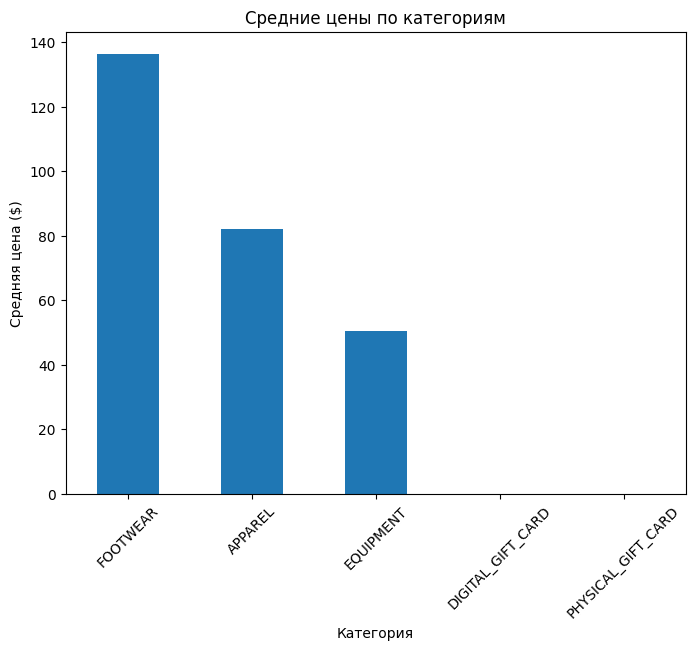

In [58]:
plt.figure(figsize=(8,6))
avg_price_category.plot(kind='bar')
plt.title('Средние цены по категориям')
plt.xlabel('Категория')
plt.ylabel('Средняя цена ($)')
plt.xticks(rotation=45)
plt.show()

Вывод по средним ценам.
*   Средняя цена всех товаров - 108 USD
*   Средняя цена категории **Footwear** - 136 USD
*   Средняя цена категории **Apparel** - 82 USD
*   Средняя цена категории **Equipment** - 50 USD








10. Нормализуем гендерные категории.

In [59]:
def normalize_gender(gender):
  if pd.isna(gender):
    return 'Unknown'
  gender = str(gender).upper()

  if gender == 'MEN':
    return 'Men'
  elif gender == 'WOMEN':
    return 'Women'
  elif gender in ['BOYS', 'GIRLS', 'BOYS|GIRLS']:
    return 'Kids'
  elif gender in ['MEN|WOMEN', 'MEN|BOYS|WOMEN|GIRLS']:
        return 'Unisex'
  else:
    return 'Other'

df_clean['gender_normalize'] = df_clean['gender_segment'].apply(normalize_gender)
print(df_clean['gender_normalize'].value_counts())

gender_normalize
Men        579987
Women      373417
Kids       252717
Unisex     234481
Unknown      6747
Other         446
Name: count, dtype: int64


11. Теперь построим график товаров по гендеру.

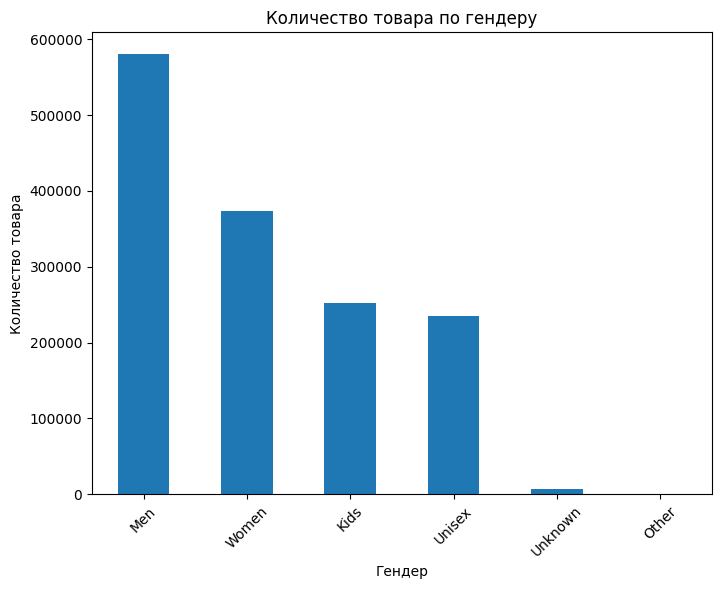

In [60]:
plt.figure(figsize=(8,6))
df_clean['gender_normalize'].value_counts().plot(kind='bar')
plt.title('Количество товара по гендеру')
plt.xlabel('Гендер')
plt.ylabel('Количество товара')
plt.xticks(rotation=45)
plt.show()

12. Узнаем среднюю цену по гендерам и построим график.

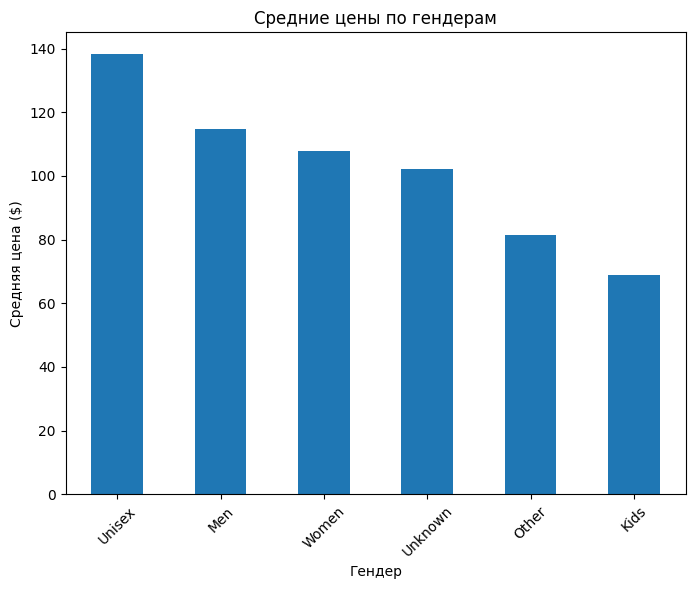

In [61]:
df_no_gift = df_clean[~df_clean['category'].isin(['PHYSICAL_GIFT_CARD', 'DIGITAL_GIFT_CARD'])]
avg_price_gender = df_no_gift.groupby('gender_normalize')['price_usd'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
avg_price_gender.plot(kind='bar')
plt.title('Средние цены по гендерам')
plt.xlabel('Гендер')
plt.ylabel('Средняя цена ($)')
plt.xticks(rotation=45)
plt.show()


13. Построим график скидок по гендерам.

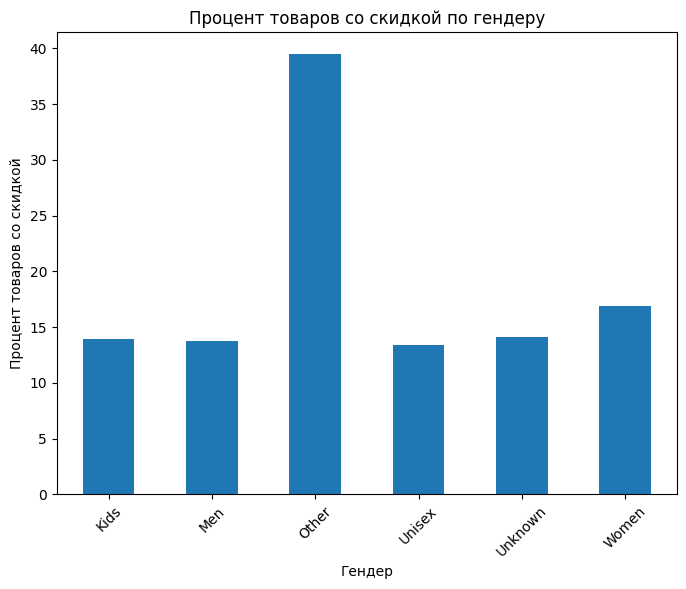

In [62]:
discount_by_gender = df_no_gift.groupby('gender_normalize')['has_discount'].mean() * 100

plt.figure(figsize=(8,6))
discount_by_gender.plot(kind='bar')
plt.title('Процент товаров со скидкой по гендеру')
plt.xlabel('Гендер')
plt.ylabel('Процент товаров со скидкой')
plt.xticks(rotation=45)
plt.show()

Выводы по гендерному анализу.
1. **Количество товаров**
- Men - 579987
- Women - 373417
- Kids - 252717
- Unisex - 234481

2. **Средние цены**
- Men - 114 USD
- Women - 107 USD
- Kids - 68 USD
- Unisex - 138 USD

3. **Процент товаров со скидкой**
- Men - 13.78%
- Women - 16.87%
- Kids - 13.93%
- Unisex - 13.38%
